In [16]:
from typing import TypedDict
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
import os
from dotenv import load_dotenv


# load environment variables
for _env_path in ["notebooks/.env", ".env"]:
    if os.path.exists(_env_path):
        load_dotenv(_env_path)
        break


# --- Structured Output Models ---

class KeywordExtractionOutput(BaseModel):
    keywords: list[str] = Field(
        description="Keywords extracted from the user query suitable for BM25 lexical search."
    )

class KeywordExpansion(BaseModel):
    keyword: str = Field(description="The original extracted keyword.")
    synonyms: list[str] = Field(
        description="Synonyms and closely related technical terms for this keyword in the context of GitHub repos."
    )

class SynonymExpansionOutput(BaseModel):
    expansions: list[KeywordExpansion] = Field(
        description="Per-keyword synonym expansions."
    )

# --- State ---

class AgentState(TypedDict):
    query: str
    keywords: list[str]
    expansions: list[dict]   # serialized KeywordExpansion objects
    bm25_terms: list[str]    # flat list of all synonyms, ready for BM25

# --- System Prompts ---

KEYWORD_EXTRACTION_SYSTEM_PROMPT = """\
You are a search query keyword extractor for AskMyBookmark -- a conversational search \
assistant that helps people search through their starred GitHub repos. \
When given a user query, extract only the keywords that carry lexical search signal: \
repo names, technology names, programming languages, domain terms, and action verbs. \
Strip conversational filler, pronouns, and stopwords.\
Ignore extracting words related to repositories, repos, or GitHub in general.\
Ignore extracting words related to favorites or starred if related to repositories or GitHub in general.\
"""

SYNONYM_EXPANSION_SYSTEM_PROMPT = """\
You are a search term expander for AskMyBookmark -- a search assistant over starred GitHub repos. \
Given a list of search keywords, generate relevant synonyms and closely related technical terms \
for each keyword in the context of software, science, technology and GitHub repositories. \
Avoid duplicating the original keywords in the synonyms list.\
"""

# --- LLMs with Structured Output ---

base_llm = ChatOpenAI(model="gpt-4o-mini")

keyword_extractor_llm = base_llm.with_structured_output(KeywordExtractionOutput)
synonym_generator_llm = base_llm.with_structured_output(SynonymExpansionOutput)

# --- Nodes ---

def extract_keywords(state: AgentState) -> dict:
    response: KeywordExtractionOutput = keyword_extractor_llm.invoke([
        SystemMessage(content=KEYWORD_EXTRACTION_SYSTEM_PROMPT),
        HumanMessage(content=state["query"]),
    ])
    return {"keywords": response.keywords}


def generate_synonyms(state: AgentState) -> dict:
    response: SynonymExpansionOutput = synonym_generator_llm.invoke([
        SystemMessage(content=SYNONYM_EXPANSION_SYSTEM_PROMPT),
        HumanMessage(content=str(state["keywords"])),
    ])
    bm25_terms = [syn for exp in response.expansions for syn in exp.synonyms]
    return {
        "expansions": [exp.model_dump() for exp in response.expansions],
        "bm25_terms": bm25_terms,
    }

# --- Graph ---

def build_graph():
    graph = StateGraph(AgentState)

    graph.add_node("keyword_extractor", extract_keywords)
    graph.add_node("synonym_generator", generate_synonyms)

    graph.set_entry_point("keyword_extractor")
    graph.add_edge("keyword_extractor", "synonym_generator")
    graph.add_edge("synonym_generator", END)

    return graph.compile()

In [17]:
app = build_graph()

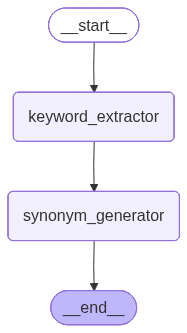

In [18]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [19]:
result = app.invoke({
    "query": "What are some top deep learning libraries I have starred?",
    "keywords": [],
    "expansions": [],
    "bm25_terms": [],
})

print("Original query :", result["query"])
print("Extracted keywords:", result["keywords"])
print("\nSynonym expansions:")
for exp in result["expansions"]:
    print(f"  {exp['keyword']:20s} → {exp['synonyms']}")
print("\nFinal BM25 terms  :", result["bm25_terms"])

Original query : What are some top deep learning libraries I have starred?
Extracted keywords: ['deep learning', 'libraries']

Synonym expansions:
  deep learning        → ['neural networks', 'machine learning', 'artificial intelligence', 'deep neural networks', 'reinforcement learning', 'convnet', 'AI algorithms', 'predictive modeling', 'supervised learning', 'unsupervised learning']
  libraries            → ['frameworks', 'packages', 'dependencies', 'modules', 'toolkits', 'software libraries', 'code repositories', 'APIs', 'components', 'dependencies management']

Final BM25 terms  : ['neural networks', 'machine learning', 'artificial intelligence', 'deep neural networks', 'reinforcement learning', 'convnet', 'AI algorithms', 'predictive modeling', 'supervised learning', 'unsupervised learning', 'frameworks', 'packages', 'dependencies', 'modules', 'toolkits', 'software libraries', 'code repositories', 'APIs', 'components', 'dependencies management']


In [20]:
result2 = app.invoke({
    "query": "Do I have any starred repositories related to Bayesian Statistics or Bayesian Modeling?",
    "keywords": [],
    "expansions": [],
    "bm25_terms": [],
})

print("Original query :", result2["query"])
print("Extracted keywords:", result2["keywords"])
print("\nSynonym expansions:")
for exp in result2["expansions"]:
    print(f"  {exp['keyword']:20s} → {exp['synonyms']}")
print("\nFinal BM25 terms  :", result2["bm25_terms"])

Original query : Do I have any starred repositories related to Bayesian Statistics or Bayesian Modeling?
Extracted keywords: ['Bayesian', 'Statistics', 'Bayesian Modeling']

Synonym expansions:
  Bayesian             → ['Bayes theorem', 'Bayesian inference', 'Posterior probability', 'Prior probability', 'Credible interval', 'Bayesian networks']
  Statistics           → ['Data analysis', 'Statistical analysis', 'Quantitative analysis', 'Descriptive statistics', 'Inferential statistics', 'Statistical modeling']
  Bayesian Modeling    → ['Bayesian analysis', 'Probabilistic modeling', 'Bayesian networks', 'Hierarchical modeling', 'Empirical Bayes', 'Bayesian regression']

Final BM25 terms  : ['Bayes theorem', 'Bayesian inference', 'Posterior probability', 'Prior probability', 'Credible interval', 'Bayesian networks', 'Data analysis', 'Statistical analysis', 'Quantitative analysis', 'Descriptive statistics', 'Inferential statistics', 'Statistical modeling', 'Bayesian analysis', 'Probabilist

In [21]:
result3 = app.invoke({
    "query": "Do I have any starred repositories related to Bayesian Statistics or Bayesian Modeling?",
    "keywords": [],
    "expansions": [],
    "bm25_terms": [],
})

print("Original query :", result3["query"])
print("Extracted keywords:", result3["keywords"])
print("\nSynonym expansions:")
for exp in result3["expansions"]:
    print(f"  {exp['keyword']:20s} → {exp['synonyms']}")
print("\nFinal BM25 terms  :", result3["bm25_terms"])

Original query : Do I have any starred repositories related to Bayesian Statistics or Bayesian Modeling?
Extracted keywords: ['Bayesian Statistics', 'Bayesian Modeling']

Synonym expansions:
  Bayesian Statistics  → ['probabilistic modeling', 'Statistical inference', "Bayes' theorem", 'posterior distribution', 'prior distribution', 'likelihood', 'Bayesian analysis', 'statistical learning', 'Bayesian networks', 'posterior predictive check']
  Bayesian Modeling    → ['Bayesian inference', 'probabilistic programming', 'statistical modeling', 'Bayesian networks', 'Markov Chain Monte Carlo (MCMC)', 'hierarchical modeling', 'data-driven simulation', 'Bayesian optimization', 'uncertainty quantification', 'parametric modeling']

Final BM25 terms  : ['probabilistic modeling', 'Statistical inference', "Bayes' theorem", 'posterior distribution', 'prior distribution', 'likelihood', 'Bayesian analysis', 'statistical learning', 'Bayesian networks', 'posterior predictive check', 'Bayesian inference',

In [22]:
result4 = app.invoke({
    "query": "What are some repos related to recommender systems that I have starred?",
    "keywords": [],
    "expansions": [],
    "bm25_terms": [],
})

print("Original query :", result4["query"])
print("Extracted keywords:", result4["keywords"])
print("\nSynonym expansions:")
for exp in result4["expansions"]:
    print(f"  {exp['keyword']:20s} → {exp['synonyms']}")
print("\nFinal BM25 terms  :", result4["bm25_terms"])

Original query : What are some repos related to recommender systems that I have starred?
Extracted keywords: ['recommender systems']

Synonym expansions:
  recommender systems  → ['recommendation engines', 'personalization algorithms', 'collaborative filtering', 'content-based filtering', 'recommendation frameworks', 'machine learning for recommendations', 'user preference modeling', 'item suggestion systems', 'predictive analytics', 'behavioral analysis']

Final BM25 terms  : ['recommendation engines', 'personalization algorithms', 'collaborative filtering', 'content-based filtering', 'recommendation frameworks', 'machine learning for recommendations', 'user preference modeling', 'item suggestion systems', 'predictive analytics', 'behavioral analysis']


In [23]:
result5 = app.invoke({
    "query": "Do I have any starred repos related to Markov Chains?",
    "keywords": [],
    "expansions": [],
    "bm25_terms": [],
})

print("Original query :", result5["query"])
print("Extracted keywords:", result5["keywords"])
print("\nSynonym expansions:")
for exp in result5["expansions"]:
    print(f"  {exp['keyword']:20s} → {exp['synonyms']}")
print("\nFinal BM25 terms  :", result5["bm25_terms"])

Original query : Do I have any starred repos related to Markov Chains?
Extracted keywords: ['Markov Chains']

Synonym expansions:
  Markov Chains        → ['Markov processes', 'stochastic processes', 'probabilistic models', 'state transitions', 'Markov models', 'hidden Markov models', 'random walks', 'chain models', 'discrete-time Markov chains', 'statistical modeling', 'dynamic systems']

Final BM25 terms  : ['Markov processes', 'stochastic processes', 'probabilistic models', 'state transitions', 'Markov models', 'hidden Markov models', 'random walks', 'chain models', 'discrete-time Markov chains', 'statistical modeling', 'dynamic systems']
